In [1]:
# This cell imports all necessary libraries used for data handling,
# visualization, model training, and evaluation

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical


In [2]:
# This cell loads the MNIST handwritten digit dataset
# It splits the data into training and testing sets

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


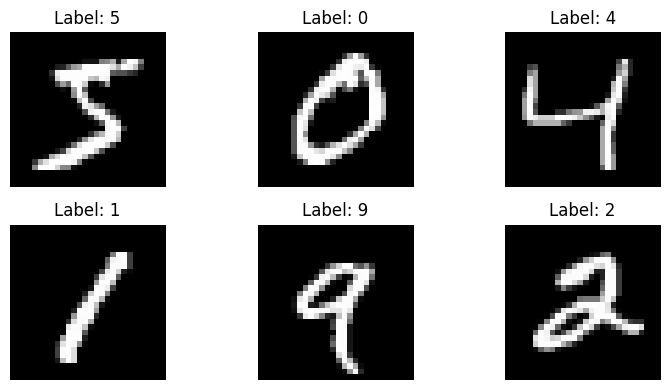

In [3]:
# This cell displays a few sample images from the dataset
# to understand what the handwritten digits look like

plt.figure(figsize=(8, 4))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
# This cell normalizes pixel values from 0–255 to 0–1
# Normalization helps the model train faster and more accurately

X_train = X_train / 255.0
X_test = X_test / 255.0


In [5]:
# This cell converts numeric labels into one-hot encoded format
# Example: 3 -> [0,0,0,1,0,0,0,0,0,0]

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [6]:
# This cell defines a simple neural network using Keras
# The model flattens the image and uses dense layers for classification

model = Sequential()

model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# This cell compiles the model by defining the optimizer,
# loss function, and evaluation metric

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [8]:
# This cell trains the model using the training data
# Validation data is used to monitor performance during training

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test)
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8247 - loss: 0.6180 - val_accuracy: 0.9508 - val_loss: 0.1677
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9563 - loss: 0.1482 - val_accuracy: 0.9649 - val_loss: 0.1179
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9699 - loss: 0.1014 - val_accuracy: 0.9680 - val_loss: 0.1023
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9774 - loss: 0.0754 - val_accuracy: 0.9729 - val_loss: 0.0856
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9810 - loss: 0.0623 - val_accuracy: 0.9742 - val_loss: 0.0822
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9862 - loss: 0.0459 - val_accuracy: 0.9724 - val_loss: 0.0839
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9885 - loss: 0.0376 - val_accuracy: 0.9772 - val_loss: 0.0746
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9912 - loss: 0.0314 - val_accuracy: 0.

In [9]:
# This cell evaluates the trained model on test data
# It prints final accuracy and loss

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9741 - loss: 0.0879
Test Accuracy: 0.9772999882698059
Test Loss: 0.07842350006103516


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


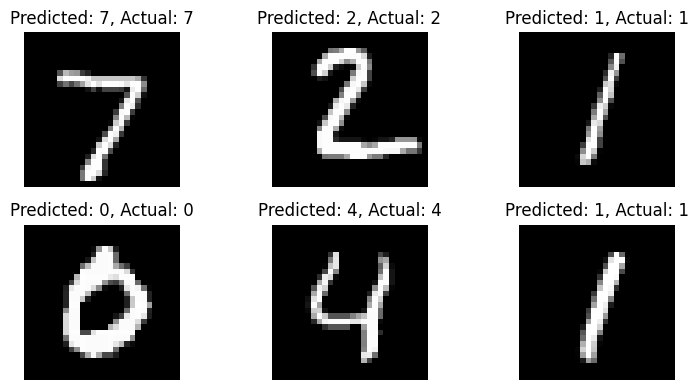

In [10]:
# This cell makes predictions on test images
# It compares predicted labels with actual labels

predictions = model.predict(X_test)

plt.figure(figsize=(8, 4))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    predicted_label = np.argmax(predictions[i])
    actual_label = np.argmax(y_test[i])
    plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()
